# Detección de Fraude con Deep Learning
## Trabajo Final - Diplomado

**Modelos:** LSTM (TensorFlow) + TabNet (PyTorch)

**Dataset:** Credit Card Fraud Detection (284,807 transacciones, 492 fraudes)

**Hardware:** GPU T4 (Google Colab)

**Version:** v2.1 — entrega final

---

### Procedimiento general seguido en este notebook

El pipeline se organiza en las siguientes etapas, en este orden: **(1)** carga y depuración del dataset (incluida la eliminación de duplicados exactos); **(2)** análisis exploratorio de datos; **(3)** partición estratificada 70/15/15 en entrenamiento, validación y prueba; **(4)** ingeniería de características, calculada **por separado en cada partición** para evitar fuga de información; **(5)** escalado de variables ajustado únicamente con el conjunto de entrenamiento; **(6)** balanceo de clases mediante SMOTE, ponderación de clases y función de pérdida focal; **(7)** selección de variables usando la importancia nativa de TabNet; **(8)** entrenamiento de dos arquitecturas de Deep Learning conceptualmente distintas (LSTM Bidireccional y TabNet); y **(9)** evaluación comparativa, con el umbral de decisión de cada modelo ajustado en validación y aplicado —sin modificarlo— sobre el conjunto de prueba, para que las métricas finales sean una estimación honesta del desempeño esperable en producción.

## 1. Instalar Dependencias

Se instalan `pytorch-tabnet` (arquitectura TabNet) e `imblearn` (provee SMOTE), las dos únicas librerías que no vienen preinstaladas en el runtime estándar de Colab.

In [5]:
# Instalamos las librerías que no vienen preinstaladas en el runtime de Colab:
#  - pytorch-tabnet: implementación de TabNet (modelo 2)
#  - imblearn: provee SMOTE, usado para remuestrear la clase minoritaria (fraude)
!pip install pytorch-tabnet imblearn -q
print("Dependencias instaladas...")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00
Dependencias instaladas...


## 2. Montar Google Drive

Se monta Google Drive para leer el CSV del dataset y, sobre todo, para que los modelos entrenados y los resultados persistan más allá de la sesión de Colab (que se borra por completo al desconectarse).

In [6]:
# Montamos Google Drive: es donde vive el CSV del dataset y donde se van a
# guardar los modelos entrenados y los resultados, para que no se pierdan al
# cerrarse la sesión de Colab.
from google.colab import drive
drive.mount('/content/drive')

# Configurar ruta del proyecto
BASE = '/content/drive/MyDrive/TRABAJO FINAL - DEEP LEARNING'
DATA = f'{BASE}/creditcard'          # CSV original (creditcard.csv)
MODELS = f'{BASE}/models'            # modelos entrenados + resultados/scaler serializados
REPORTS = f'{BASE}/reports/figures'  # carpeta reservada para figuras exportadas

import os
# exist_ok=True: no falla si las carpetas ya existen de una corrida anterior
os.makedirs(MODELS, exist_ok=True)
os.makedirs(REPORTS, exist_ok=True)
print(f"Proyecto: {BASE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Proyecto: /content/drive/MyDrive/TRABAJO FINAL - DEEP LEARNING


## 3. Imports y Configuración

Se importan las librerías de datos (`numpy`/`pandas`), visualización (`matplotlib`/`seaborn`), los frameworks de Deep Learning (`TensorFlow` para el LSTM, `PyTorch` + `pytorch-tabnet` para TabNet) y las utilidades de `scikit-learn`/`imblearn` para preprocesamiento, partición, métricas y remuestreo.

Se fijan semillas aleatorias (`np.random.seed`, `tf.random.set_seed`, `torch.manual_seed`) para favorecer la reproducibilidad entre corridas. Es importante ser explícitos sobre el alcance real de esto: las semillas no garantizan determinismo total en GPU, ya que las operaciones de las capas recurrentes sobre cuDNN no son deterministas por defecto salvo que se activen configuraciones adicionales (no incluidas aquí). Es esperable observar variaciones pequeñas entre corridas.

In [7]:
import warnings
warnings.filterwarnings('ignore')          # silencia warnings no criticos de librerias
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # silencia logs internos de TensorFlow/CUDA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle   # para serializar el scaler y el diccionario de resultados
import time     # para medir tiempo de entrenamiento de cada modelo

# Semilla de NumPy: hace reproducibles operaciones como el muestreo de SMOTE
np.random.seed(42)

# --- TensorFlow (para el modelo LSTM) ---
import tensorflow as tf
from tensorflow.keras import backend as K
tf.random.set_seed(42)   # semilla de TF: inicializacion de pesos, shuffling, etc.

# --- Scikit-learn (preprocesamiento, particion y metricas) ---
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve,
                             precision_recall_curve, average_precision_score,
                             f1_score, accuracy_score, precision_score,
                             recall_score, roc_auc_score)
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

# --- PyTorch (para el modelo TabNet) ---
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
torch.manual_seed(42)            # semilla de PyTorch en CPU
torch.cuda.manual_seed_all(42)   # semilla de PyTorch en GPU (si aplica)

# Nota de reproducibilidad: estas semillas fijan los generadores de numeros
# aleatorios de NumPy/TensorFlow/PyTorch, pero NO garantizan determinismo
# total en GPU (las capas recurrentes sobre cuDNN usan operaciones no
# deterministas por defecto salvo que se activen flags adicionales de
# determinismo, que aqui no se configuran). Es esperable ver variaciones
# pequeñas entre corridas.

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 4. Cargar Dataset

Se carga el CSV original y se verifica su integridad básica (forma, tasa de fraude, ausencia de valores nulos) antes de continuar.

In [8]:
# Cargar el CSV original
df = pd.read_csv(f'{DATA}/creditcard.csv')
print(f"Shape: {df.shape}")
print(f"Fraudes: {sum(df['Class']==1)} / {len(df)} ({sum(df['Class']==1)/len(df)*100:.3f}%)")
print(f"Ratio desbalance: {sum(df['Class']==0)/sum(df['Class']==1):.0f}:1")

# Verificar y eliminar nulos (chequeo defensivo: en este dataset no deberia haber ninguno)
print(f'Valores nulos totales: {df.isnull().sum().sum()}')
df = df.dropna().reset_index(drop=True)  # reset_index: re-numera el indice tras el posible drop
print(f'Shape sin nulos: {df.shape}')
df.head()

Shape: (284807, 31)
Fraudes: 492 / 284807 (0.173%)
Ratio desbalance: 578:1
Valores nulos totales: 0
Shape sin nulos: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 5. Análisis Exploratorio de Datos (EDA)

Esta sección caracteriza el dataset en tres frentes: **(5.1)** el desbalance de clases y la calidad de los datos —incluida la decisión de eliminar registros duplicados—, **(5.2)** el comportamiento de `Amount` y `Time` por clase, y **(5.3)** la estructura de varianza de las componentes PCA.

### 5.1 Distribución de Clases y Estadísticas Básicas

Se cuantifica el desbalance de clases y se depura el dataset eliminando 1.081 registros exactamente duplicados (detectados con `duplicated()`). **Por qué se eliminan:** el dataset se particiona más adelante de forma aleatoria; si una fila duplicada existe dos veces, existe una probabilidad real de que una copia caiga en entrenamiento y la otra en prueba, permitiendo que el modelo sea evaluado sobre una transacción idéntica a otra que ya memorizó — una forma de contaminación entre particiones que infla artificialmente las métricas de prueba. Todos los estadísticos calculados de aquí en adelante corresponden ya al dataset depurado (283.726 filas, 473 fraudes).

In [9]:
# ============================================================
# 5.1 Distribucion de clases y estadisticas basicas
# ============================================================

# --- Diagnostico ANTES de depurar ---
n_total = len(df)
n_fraudes = df['Class'].sum()       # Class es 0/1 -> sumar la columna cuenta los fraudes
n_normales = n_total - n_fraudes
pct_fraude = n_fraudes / n_total * 100

print('=' * 50)
print('ESTADISTICAS DEL DATASET')
print('=' * 50)
print(f'Total transacciones: {n_total:,}')
print(f'Normales: {n_normales:,} ({n_normales/n_total*100:.2f}%)')
print(f'Fraudes: {n_fraudes:,} ({pct_fraude:.3f}%)')
print(f'Ratio desbalance: {n_normales//n_fraudes}:1')

# Verificar valores nulos y duplicados
print(f'\nValores nulos: {df.isnull().sum().sum()}')
print(f'Duplicados: {df.duplicated().sum()}')

# Eliminar duplicados exactos: evita que la misma fila termine repartida
# entre train y test tras el split (fuga por contaminacion train/test)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape sin duplicados: {df.shape}')

# --- Recalcular estadisticas YA depuradas: de aqui en adelante el notebook
# trabaja sobre este dataset sin duplicados ---
n_total = len(df)
n_fraudes = df['Class'].sum()
n_normales = n_total - n_fraudes
pct_fraude = n_fraudes / n_total * 100

# Estadisticas descriptivas de Amount por clase
print('\n' + '=' * 50)
print('ESTADISTICAS DE AMOUNT POR CLASE')
print('=' * 50)
print(df.groupby('Class')['Amount'].describe().round(2))

# 5-number summary de las features PCA (V1-V28) por clase
print('\n' + '=' * 50)
print('FEATURES PCA (V1-V28) - RANGO POR CLASE')
print('=' * 50)
v_cols = [f'V{i}' for i in range(1, 29)]
# .min()/.max() por clase da una tabla (2 filas x 28 cols); .min(axis=1)/.max(axis=1)
# reduce esas 28 columnas a un solo numero: el minimo/maximo visto en CUALQUIER
# componente V, para cada clase.
v_min = df.groupby('Class')[v_cols].min().min(axis=1)
v_max = df.groupby('Class')[v_cols].max().max(axis=1)
for c in [0, 1]:
    label = 'Normal' if c == 0 else 'Fraude'
    print(f'  {label}: min={v_min[c]:.4f}, max={v_max[c]:.4f}')

ESTADISTICAS DEL DATASET
Total transacciones: 284,807
Normales: 284,315 (99.83%)
Fraudes: 492 (0.173%)
Ratio desbalance: 577:1

Valores nulos: 0
Duplicados: 1081
Shape sin duplicados: (283726, 31)

ESTADISTICAS DE AMOUNT POR CLASE
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      283253.0   88.41  250.38  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.87  260.21  0.0  1.00   9.82  105.89   2125.87

FEATURES PCA (V1-V28) - RANGO POR CLASE
  Normal: min=-113.7433, max=120.5895
  Fraude: min=-43.5572, max=27.2028


### 5.2 Visualización de Variables Principales

Panel de cuatro gráficos, cada uno resolviendo de forma distinta el mismo problema de fondo (una clase 599 veces más frecuente que la otra): distribución de clases, `Amount` por clase en escala logarítmica (para no dejar invisibles los montos bajos frente a los extremos), distribución horaria por clase normalizada por densidad (para poder comparar la *forma* de ambas curvas pese a su enorme diferencia de tamaño muestral), y las variables más correlacionadas —positiva y negativamente— con la clase objetivo.

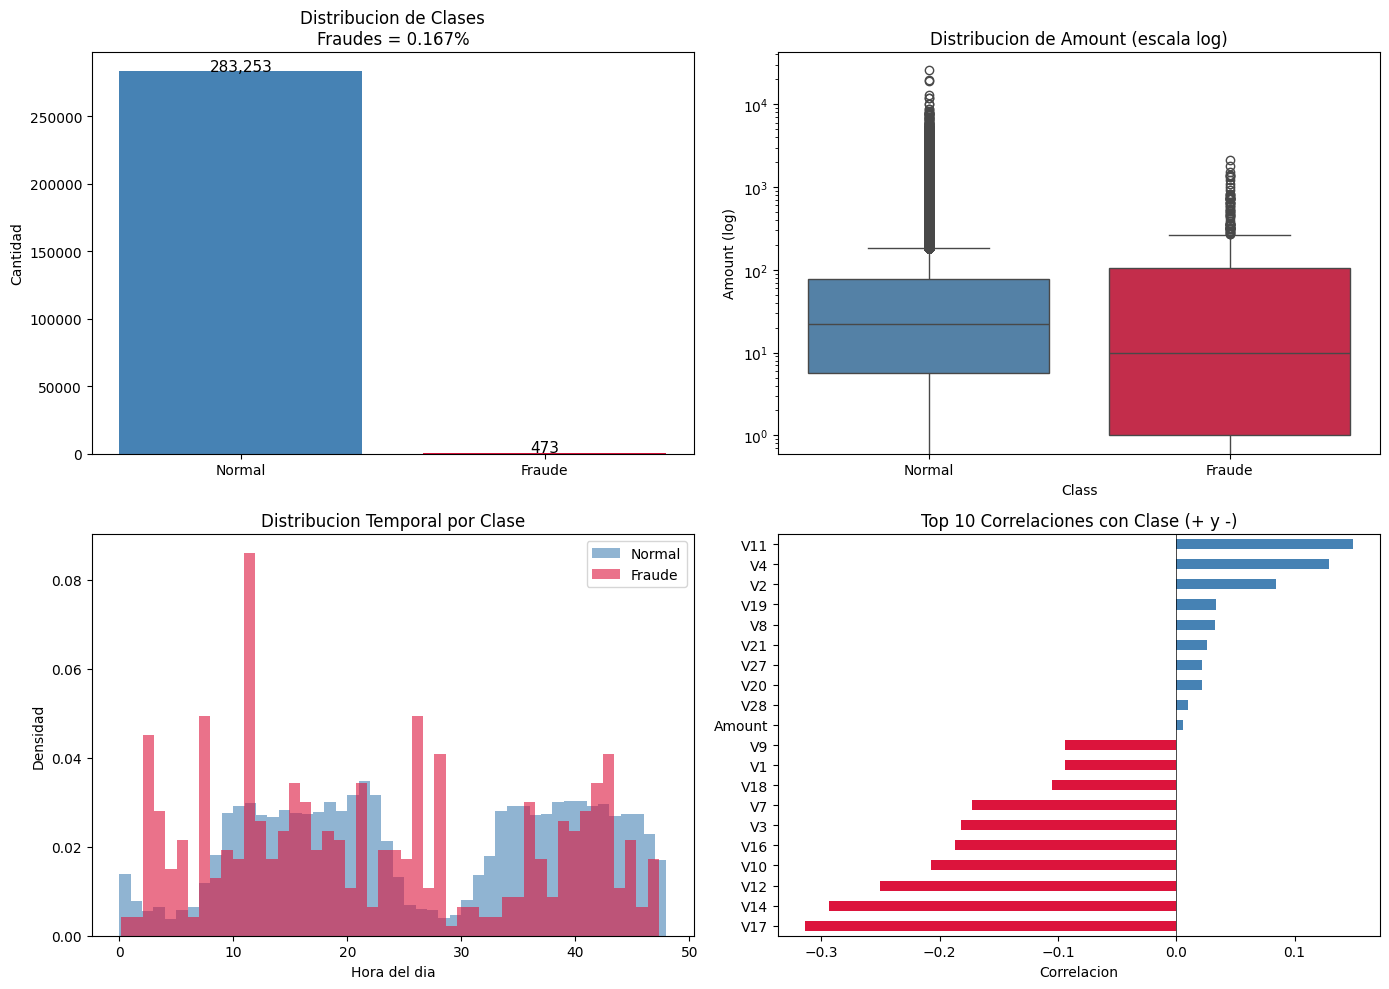

In [10]:
# ============================================================
# 5.2 Visualizacion de variables principales (panel 2x2)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. Distribucion de clases (conteo con etiquetas numericas) ---
colors = ['steelblue', 'crimson']
axes[0,0].bar(['Normal', 'Fraude'], [n_normales, n_fraudes], color=colors)
axes[0,0].set_ylabel('Cantidad')
axes[0,0].set_title(f'Distribucion de Clases\nFraudes = {pct_fraude:.3f}%')
for i, v in enumerate([n_normales, n_fraudes]):
    axes[0,0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

# --- 2. Amount por clase, en escala logaritmica ---
# La escala log es necesaria: sin ella, los montos extremos (hasta ~25.691)
# aplastarian visualmente la variacion entre $0 y $200, donde ocurre la
# mayoria de las transacciones.
df_box = df.copy()
df_box['Class'] = df_box['Class'].map({0: 'Normal', 1: 'Fraude'})
sns.boxplot(x='Class', y='Amount', data=df_box, ax=axes[0,1], palette=colors)
axes[0,1].set_yscale('log')
axes[0,1].set_title('Distribucion de Amount (escala log)')
axes[0,1].set_ylabel('Amount (log)')

# --- 3. Distribucion horaria por clase ---
# density=True normaliza cada histograma para que su area sume 1: con solo
# 473 fraudes contra 283.253 legitimas, un histograma de CONTEOS haria
# invisible la curva de fraude.
for c, label, color in [(0, 'Normal', 'steelblue'), (1, 'Fraude', 'crimson')]:
    subset = df[df['Class'] == c]['Time'] / 3600
    axes[1,0].hist(subset, bins=48, alpha=0.6, label=label, color=color, density=True)
axes[1,0].set_xlabel('Hora del dia')
axes[1,0].set_ylabel('Densidad')
axes[1,0].set_title('Distribucion Temporal por Clase')
axes[1,0].legend()

# --- 4. Correlacion de cada variable numerica con la clase objetivo ---
corr = df.corr(numeric_only=True)['Class'].drop('Class').sort_values()
top10 = pd.concat([corr.head(10), corr.tail(10)])   # 10 mas negativas + 10 mas positivas
top10.plot.barh(ax=axes[1,1], color=['crimson' if v < 0 else 'steelblue' for v in top10.values])
axes[1,1].axvline(x=0, color='black', linewidth=0.5)
axes[1,1].set_title('Top 10 Correlaciones con Clase (+ y -)')
axes[1,1].set_xlabel('Correlacion')

plt.tight_layout()
plt.show()

### 5.3 Análisis de Componentes PCA (V1-V28)

Se examina cómo se reparte la varianza entre las 28 componentes PCA ya publicadas en el dataset. Nota de interpretación: como V1–V28 son el resultado de un PCA aplicado por los autores originales, esta cifra describe la estructura de varianza *entre esas 28 columnas*, no qué fracción de las variables transaccionales originales (nunca publicadas) llegan a capturar.

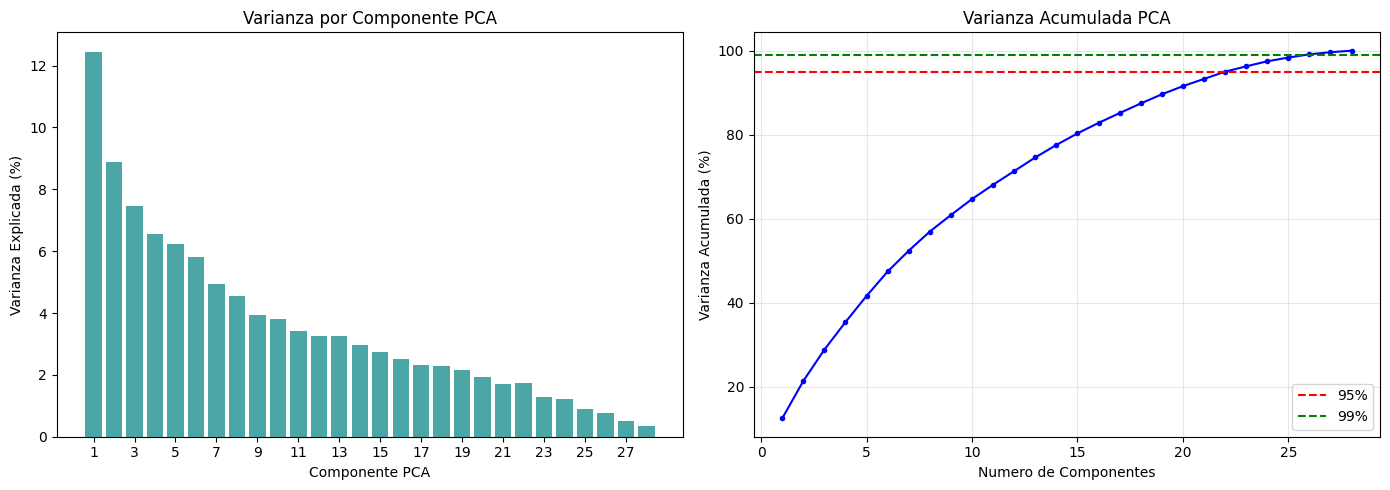

Componentes para 95% varianza: 23
Componentes para 99% varianza: 26


In [11]:
# ============================================================
# 5.3 Analisis de las componentes PCA (V1-V28)
# ============================================================
# Nota de interpretacion: V1-V28 YA son el resultado de un PCA aplicado por
# los autores originales del dataset. Esta varianza describe como se reparte
# la varianza ENTRE esas 28 columnas publicadas, no que fraccion de las
# variables originales (nunca publicadas) capturan.
v_cols = [f'V{i}' for i in range(1, 29)]
explained_var = df[v_cols].var().values
explained_var_pct = explained_var / explained_var.sum() * 100
cumulative_var = np.cumsum(explained_var_pct)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza individual por componente
axes[0].bar(range(1, 29), explained_var_pct, color='teal', alpha=0.7)
axes[0].set_xlabel('Componente PCA')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Varianza por Componente PCA')
axes[0].set_xticks(range(1, 29, 2))

# Varianza acumulada, con lineas de referencia en 95% y 99%
axes[1].plot(range(1, 29), cumulative_var, 'b-o', markersize=3)
axes[1].axhline(y=95, color='r', linestyle='--', label='95%')
axes[1].axhline(y=99, color='g', linestyle='--', label='99%')
axes[1].set_xlabel('Numero de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada PCA')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# searchsorted busca el primer indice donde la curva acumulada alcanza el
# umbral (95 o 99); +1 convierte ese indice (base 0) en una CANTIDAD de componentes
n_95_var = np.searchsorted(cumulative_var, 95) + 1
n_99_var = np.searchsorted(cumulative_var, 99) + 1
print(f'Componentes para 95% varianza: {n_95_var}')
print(f'Componentes para 99% varianza: {n_99_var}')

## 6. Feature Engineering

Se definen y calculan las variables derivadas a partir de `Time`, `Amount` y V1–V28: transformaciones de monto, estadísticos temporales, medias móviles, agregados por fila sobre las componentes PCA, y ratios/interacciones entre las variables más relevantes. La función `create_features()` se define aquí, pero **se invoca en la siguiente sección tres veces por separado** —una por cada partición del dataset ya dividida—, que es lo que garantiza que ningún estadístico calculado sobre múltiples filas (como el z-score de `Amount` o la frecuencia por hora) se filtre entre entrenamiento, validación y prueba.

In [12]:
from scipy import stats as st


def create_features(df):
    """Genera las variables derivadas a partir de Time, Amount y V1-V28.

    IMPORTANTE sobre fuga de informacion: esta funcion calcula varios
    estadisticos (zscore, frecuencia por hora, medias moviles) sobre TODAS
    las filas del DataFrame que recibe. Es segura contra fuga de informacion
    UNICAMENTE porque, en la seccion "Preparacion de Datos", se la llama tres
    veces por separado -una por cada particion ya dividida (train/val/test)-
    de modo que ningun estadistico de una particion se filtra hacia otra.
    Si se llamara una sola vez sobre el dataset completo antes de particionar,
    esta proteccion desaparece.
    """
    df = df.copy()
    v_cols = [f'V{i}' for i in range(1, 29)]

    # --- Amount ---
    df['Amount_log'] = np.log1p(df['Amount'])  # log1p (no log) porque Amount puede ser 0
    df['Amount_log_cat'] = pd.cut(np.log1p(df['Amount']), bins=10, labels=False).astype(float)
    df['Amount_zscore'] = np.abs(st.zscore(df['Amount']))  # cuantas std se aleja de la media (de ESTA particion)

    # --- Time ---
    df['Time_hour'] = (df['Time'] / 3600) % 24  # segundos -> hora del dia (0-24), el modulo alinea ambos dias
    # Cuenta transacciones que comparten el mismo Time_hour EXACTO dentro de esta particion
    # (en la practica, mas bien "transacciones en el mismo instante" que una frecuencia horaria general)
    df['Transaction_frequency'] = df.groupby('Time_hour')['Time_hour'].transform('count')

    # --- Estadisticos moviles (rolling) de Amount ---
    # rolling() en pandas es causal por defecto: solo mira hacia atras, nunca hacia
    # adelante, por lo que no introduce fuga temporal dentro de la particion.
    df['Amount_roll_mean_5'] = df['Amount'].rolling(window=5, min_periods=1).mean()
    # min_periods=1: las primeras filas (sin 5 previas completas) usan las que haya,
    # en vez de quedar en NaN y perderse en el dropna() final.
    df['Amount_roll_std_5'] = df['Amount'].rolling(window=5, min_periods=1).std().fillna(0)
    df['Amount_roll_mean_10'] = df['Amount'].rolling(window=10, min_periods=1).mean()
    df['Amount_roll_ratio'] = df['Amount'] / (df['Amount_roll_mean_5'] + 1e-6)  # eps evita division por cero

    # --- Estadisticos de V1-V28 POR FILA (axis=1: a traves de las 28 columnas,
    # para cada transaccion individual) -> sin ningun riesgo de fuga entre particiones ---
    df['V_mean'] = df[v_cols].mean(axis=1)
    df['V_std'] = df[v_cols].std(axis=1)
    df['V_max'] = df[v_cols].max(axis=1)
    df['V_min'] = df[v_cols].min(axis=1)
    df['V_median'] = df[v_cols].median(axis=1)
    df['V_abs_sum'] = df[v_cols].abs().sum(axis=1)
    df['V_count_neg'] = (df[v_cols] < 0).sum(axis=1)
    df['V_count_pos'] = (df[v_cols] > 0).sum(axis=1)

    # --- Ratios entre componentes V mas relevantes (segun EDA / importancia) ---
    df['V1_V2_ratio'] = df['V1'] / (df['V2'].abs() + 1e-6)
    df['V3_V4_ratio'] = df['V3'] / (df['V4'].abs() + 1e-6)
    df['V12_V14_ratio'] = df['V12'] / (df['V14'].abs() + 1e-6)

    # --- Amount x V: relaciona el monto con el perfil PCA de la propia transaccion ---
    df['Amount_V_ratio'] = df['Amount'] / (np.abs(df['V_mean']) + 1e-6)
    df['Amount_V_std_ratio'] = df['Amount'] / (df['V_std'] + 1e-6)

    # dropna: pd.cut puede generar NaN en valores fuera de los bins definidos
    # reset_index: renumera el indice tras el posible descarte de filas
    df = df.dropna().reset_index(drop=True)
    return df

## 7. Preparación de Datos

Esta es la sección que concentra las decisiones metodológicas centrales del preprocesamiento: la partición estratificada 70/15/15, el ordenamiento cronológico dentro de cada partición, la aplicación de `create_features()` de forma independiente por partición, el escalado (ajustado únicamente con entrenamiento y solo *aplicado* — nunca reajustado — en validación/prueba), el remuestreo con SMOTE (exclusivamente sobre entrenamiento, con una proporción objetivo de 0,3 y no de 1:1, para no generar una cantidad excesiva de ejemplos sintéticos a partir de tan pocos fraudes reales) y el cálculo de los pesos de clase que se usarán en la función de pérdida del LSTM.

In [13]:
# ============================================================
# Configuracion
# ============================================================
SEQ = 5          # longitud de la ventana temporal que consume el LSTM
FN_COST = 150    # costo de negocio de un falso negativo (fraude no detectado)
FP_COST = 25     # costo de negocio de un falso positivo (bloqueo de tx legitima)
# La razon 150:25 (6 a 1) es la que despues determina, matematicamente, el
# umbral optimo de decision: dejar pasar un fraude sale mucho mas caro que
# una falsa alarma, asi que conviene un umbral que privilegie el Recall.

# Definir grupos de features. Se separan en dos grupos porque conviene
# escalarlos con tecnicas distintas (ver mas abajo):
#  - robust_cols: variables propensas a outliers (derivadas de Amount y
#    agregados de V) -> RobustScaler (usa mediana/RIQ, poco sensible a extremos)
#  - standard_cols: ratios/conteos/hora, distribuciones mas simetricas -> StandardScaler
pca_cols = [f'V{i}' for i in range(1, 29)]
robust_cols = ['Amount_log','Amount_log_cat','Amount_zscore',
               'Amount_roll_mean_5','Amount_roll_std_5','Amount_roll_mean_10','Amount_roll_ratio',
               'Amount_V_ratio','Amount_V_std_ratio',
               'V_mean','V_std','V_max','V_min','V_median','V_abs_sum']
standard_cols = ['Time_hour','Transaction_frequency',
                 'V1_V2_ratio','V3_V4_ratio','V12_V14_ratio',
                 'V_count_neg','V_count_pos']
extra_cols = []
interaction_cols = []
feature_cols = pca_cols + robust_cols + standard_cols + extra_cols + interaction_cols


# ============================================================
# Particion 70/15/15, estratificada por Class
# ============================================================
# stratify=df['Class'] preserva la proporcion de fraude (~0.167%) en las tres
# particiones; sin esto, con una clase tan rara, un split puramente aleatorio
# podria dejar por azar muy pocos (o demasiados) fraudes en alguna particion.
df_train_raw, df_temp_raw = train_test_split(df, test_size=0.30, random_state=42, stratify=df['Class'])
df_val_raw, df_test_raw = train_test_split(df_temp_raw, test_size=0.5, random_state=42, stratify=df_temp_raw['Class'])

# Ordenar por Time DENTRO de cada particion (ya dividida), para que los
# estadisticos moviles (rolling) de create_features() y las secuencias del
# LSTM operen sobre filas en orden cronologico ascendente.
df_train_raw = df_train_raw.sort_values('Time').reset_index(drop=True)
df_val_raw = df_val_raw.sort_values('Time').reset_index(drop=True)
df_test_raw = df_test_raw.sort_values('Time').reset_index(drop=True)

# Feature engineering por separado en cada split
# (evita que zscore, groupby, rolling usen datos de test)
df_train = create_features(df_train_raw)
df_val = create_features(df_val_raw)
df_test = create_features(df_test_raw)
print(f"Features: {len(feature_cols)}")
print(f"Train: {len(df_train)} ({df_train['Class'].sum()} fraud)")
print(f"Val: {len(df_val)} ({df_val['Class'].sum()} fraud)")
print(f"Test: {len(df_test)} ({df_test['Class'].sum()} fraud)")

# ============================================================
# Escalado: fit SOLO en train, transform en val/test
# ============================================================
# fit_transform aprende los parametros (mediana/RIQ o media/std) UNICAMENTE
# de train; val y test solo usan transform(), reutilizando esos parametros
# ya aprendidos. Asi ningun estadistico de val/test se filtra hacia el
# preprocesamiento.
scaler_robust = RobustScaler()
scaler_standard = StandardScaler()
avail_robust = [c for c in robust_cols if c in df_train.columns]
avail_standard = [c for c in standard_cols if c in df_train.columns]

df_train[avail_robust] = scaler_robust.fit_transform(df_train[avail_robust])
df_val[avail_robust] = scaler_robust.transform(df_val[avail_robust])
df_test[avail_robust] = scaler_robust.transform(df_test[avail_robust])

df_train[avail_standard] = scaler_standard.fit_transform(df_train[avail_standard])
df_val[avail_standard] = scaler_standard.transform(df_val[avail_standard])
df_test[avail_standard] = scaler_standard.transform(df_test[avail_standard])

X_train = df_train[feature_cols].values
X_val = df_val[feature_cols].values
X_test = df_test[feature_cols].values
y_train = df_train['Class'].values
y_val = df_val['Class'].values
y_test = df_test['Class'].values

# ============================================================
# SMOTE: remuestreo sintetico SOLO sobre entrenamiento
# ============================================================
# sampling_strategy=0.3 -> ~1 fraude sintetico por cada 3.3 legitimas (no 1:1).
# Con solo 331 fraudes reales en train, balancear a 1:1 exigiria ~198.000
# sinteticos: casi todos serian interpolaciones dentro del mismo puñado de
# fraudes originales, con alto riesgo de que el modelo aprenda un "manifold"
# de fraude artificialmente suave. 0.3 es un compromiso: rebalancea la señal
# de gradiente sin llevar la generacion sintetica a ese extremo.
smote = SMOTE(sampling_strategy=0.3, random_state=42)
X_bal, y_bal = smote.fit_resample(X_train, y_train)
print(f"Balanced: {sum(y_bal==1)} fraud / {len(y_bal)} total")

# ============================================================
# Pesos de clase (para ponderar la funcion de perdida del LSTM)
# ============================================================
# Calculados sobre la proporcion ORIGINAL de train (~1:600, sin SMOTE).
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

Features: 50
Train: 198608 (331 fraud)
Val: 42559 (71 fraud)
Test: 42559 (71 fraud)
Balanced: 59483 fraud / 257760 total


## 8. Funciones Auxiliares

Se definen las cinco funciones reutilizadas en el resto del notebook: `create_sequences` (construye las ventanas temporales para el LSTM), `find_best_threshold` (busca el umbral de decisión que maximiza el ROI de negocio, siempre sobre datos de validación), `evaluate_model` (calcula el paquete completo de métricas reportadas), `focal_loss_tf` (la función de pérdida focal usada por el LSTM para lidiar con el desbalance) y `best_f1` (una cota superior teórica de referencia, no un umbral utilizable en producción).

In [14]:
def create_sequences(data, labels, seq_length):
    """Construye ventanas deslizantes de `seq_length` filas consecutivas.

    Cada ventana usa como etiqueta la de su ULTIMA fila (diseño "muchos a
    uno"): el LSTM recibe `seq_length` pasos de contexto y predice si la
    transaccion mas reciente de esa ventana es fraude.
    """
    sequences, seq_labels = [], []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
        seq_labels.append(labels[i + seq_length - 1])
    return np.array(sequences), np.array(seq_labels)


def find_best_threshold(y_true, y_scores):
    """Busca, por fuerza bruta, el umbral que maximiza el ROI de negocio.

    ROI = beneficio_neto / costo_incurrido * 100, donde:
      beneficio_neto   = tp*FN_COST - fn*FN_COST - fp*FP_COST
      costo_incurrido  = fn*FN_COST + fp*FP_COST

    Debe llamarse SIEMPRE con datos de VALIDACION (nunca de test): ajustar
    el umbral mirando las etiquetas de prueba equivaldria a elegir un
    hiperparametro observando la respuesta que se quiere predecir.
    """
    best_roi, best_t = -999, 0.5
    for t in np.arange(0.05, 0.9, 0.002):
        yp = (y_scores > t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, yp).ravel()
        roi = (tp*FN_COST - fn*FN_COST - fp*FP_COST) / (fn*FN_COST + fp*FP_COST + 1e-10) * 100
        if roi > best_roi:
            best_roi, best_t = roi, t
    return best_t, best_roi


def evaluate_model(y_true, y_pred, y_scores, model_name):
    """Calcula el paquete completo de metricas reportadas para un modelo:
    Accuracy/Precision/Recall/F1 (umbral fijo), ROC-AUC/PR-AUC (todos los
    umbrales, calculadas sobre las probabilidades continuas y_scores), la
    matriz de confusion, y el desglose economico (ahorro, costos, ROI).
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    savings = tp * FN_COST
    cost_fn = fn * FN_COST
    cost_fp = fp * FP_COST
    total_cost = cost_fn + cost_fp
    return {
        'model': model_name, 'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_scores),
        'pr_auc': average_precision_score(y_true, y_scores),
        'cm': cm, 'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'savings': savings, 'cost_fn': cost_fn, 'cost_fp': cost_fp,
        'total_cost': total_cost,
        'net_benefit': savings - total_cost,
        'roi': (savings - total_cost) / (total_cost + 1e-10) * 100,
    }


def focal_loss_tf(gamma=2.0, alpha=0.75):
    """Fabrica de la funcion de perdida focal (Lin et al., 2017) usada por el LSTM.

    Por que: con 599:1 de desbalance, la entropia cruzada estandar esta
    dominada por la enorme mayoria de ejemplos "faciles" (legitimos). La
    perdida focal reduce el peso de esos ejemplos faciles y concentra el
    gradiente en los dificiles (tipicamente, fraudes mal clasificados):
      pt           = probabilidad asignada a la clase VERDADERA
      alpha_t      = peso de clase (alpha para fraude, 1-alpha para legitima)
      focal_weight = alpha_t * (1 - pt)^gamma  -> ~0 si pt es alto (facil),
                     ~alpha_t si pt es bajo (dificil)
    """
    def focal_loss_fn(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())  # evita log(0)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        focal_weight = alpha_t * K.pow(1.0 - pt, gamma)
        cross_entropy = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
        return K.mean(focal_weight * cross_entropy)
    return focal_loss_fn


def best_f1(y_true, probs):
    """F1-Score maximo teoricamente alcanzable recorriendo TODOS los umbrales.

    Uso exclusivamente diagnostico (cota superior): requiere conocer de
    antemano las etiquetas verdaderas del conjunto evaluado, por lo que NO
    es un umbral utilizable en produccion.
    """
    prec, rec, _ = precision_recall_curve(y_true, probs)
    f1_scores = 2 * prec * rec / (prec + rec + 1e-10)
    best_idx = np.argmax(f1_scores)
    return f1_scores[best_idx]


print("Funciones definidas")

Funciones definidas


## 9. Feature Selection para LSTM (solo train)

Se entrena un TabNet preliminar cuyo único propósito es obtener el ranking de importancia de las 50 variables (un subproducto nativo de su mecanismo de atención), y a partir de él se seleccionan las variables que acumulan el 95% de la importancia (con un mínimo de 30). Este subconjunto reducido se usa **solo para el LSTM** — TabNet, en su modelo final (sección 11), sigue utilizando las 50 variables completas, porque ya realiza su propia selección interna en cada paso de atención, mientras que el LSTM multiplica cada variable ×5 al construir las secuencias, por lo que reducir la dimensionalidad de entrada lo hace más liviano y menos propenso a sobreajustar.

In [15]:
print("Entrenando TabNet para feature importance...")
t0 = time.time()

# Split X_bal internamente para feature selection
# (eval_set propio de TabNet, requerido para su early stopping; se toma del
# conjunto YA balanceado por SMOTE, no del train original)
from sklearn.model_selection import train_test_split
X_bal_inner, X_bal_val_inner, y_bal_inner, y_bal_val_inner = train_test_split(
    X_bal, y_bal, test_size=0.15, random_state=42, stratify=y_bal)

tabnet_full = TabNetClassifier(
    n_d=32, n_a=32,          # dimension de las capas de decision/atencion
    n_steps=5,               # cantidad de pasos de decision secuenciales (atencion)
    gamma=1.3,                # relajacion: que tanto puede reusarse una variable entre pasos
    n_independent=2, n_shared=2,   # bloques GLU independientes / compartidos por paso
    lambda_sparse=1e-3,       # penalizacion de dispersion sobre las mascaras de atencion
    optimizer_fn=torch.optim.Adam, optimizer_params=dict(lr=1e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},   # LR *= 0.9 cada 10 epocas
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',       # mascaras de atencion realmente dispersas (con ceros exactos)
    verbose=0, device_name=DEVICE)

# eval_metric: la ULTIMA metrica de la lista ('logloss') es la que gobierna
# el early stopping (patience=10 epocas sin mejorar), no 'auc'.
tabnet_full.fit(X_bal_inner, y_bal_inner,
                eval_set=[(X_bal_val_inner, y_bal_val_inner)],
                eval_metric=['auc', 'logloss'], max_epochs=50, patience=10,
                batch_size=4096, virtual_batch_size=512)

print(f"Tiempo: {time.time()-t0:.1f}s")

# --- Importancia de variables (subproducto nativo de TabNet, via sus mascaras de atencion) ---
importance = tabnet_full.feature_importances_
feat_imp = pd.Series(importance, index=feature_cols).sort_values(ascending=False)
cumulative = np.cumsum(feat_imp.values) / feat_imp.values.sum() * 100
n_95 = np.searchsorted(cumulative, 95) + 1
MIN_FEATURES = 30
n_sel = max(n_95, MIN_FEATURES)   # al menos 30 variables, o mas si hacen falta para el 95%

# Initialize n_features with the current number of features before any filtering
n_features = len(feature_cols)

print(f"\nTop 10 features:")
for i_idx, (fn, fi) in enumerate(feat_imp.head(10).items()):
    print(f"  {i_idx+1:2d}. {fn:<35s} {fi:.6f}")
print(f"\nFeatures para 95% importancia: {n_95}")
print(f"Features con importancia ~0: {(importance < 1e-6).sum()}/{n_features}")

# Filtrar features con importancia ~0 (que ningun paso de atencion uso de forma
# significativa) para ambos modelos
noise_mask = importance > 1e-6
feature_cols = [f for f, m in zip(feature_cols, noise_mask) if m]

X_train = X_train[:, noise_mask]
X_bal = X_bal[:, noise_mask]
X_val = X_val[:, noise_mask]
X_test = X_test[:, noise_mask]

# Re-normalizar importancias sin features ruidosas
# (necesario: si se eliminaron columnas, los porcentajes acumulados de antes
# ya no suman 100% y el criterio del 95% quedaria mal calibrado)
importance = importance[noise_mask]
importance = importance / importance.sum()
feat_imp = pd.Series(importance, index=feature_cols).sort_values(ascending=False)
cumulative = np.cumsum(feat_imp.values) / feat_imp.values.sum() * 100
n_95 = np.searchsorted(cumulative, 95) + 1
MIN_FEATURES = 30
n_sel = max(n_95, MIN_FEATURES)

print(f"\nFeatures sin ruido: {n_features} ({(~noise_mask).sum()} eliminadas)")

# Seleccionar features SOLO para el LSTM (TabNet final usa las 50 completas:
# ya hace su propia seleccion interna en cada paso de atencion; el LSTM, en
# cambio, multiplica cada variable x5 al armar secuencias, asi que reducir
# dimensionalidad lo hace mas liviano y menos propenso a sobreajustar)
selected_features = feat_imp.head(n_sel).index.tolist()
sel_idx = [feature_cols.index(f) for f in selected_features]
X_train_sel = X_train[:, sel_idx]
X_bal_sel = X_bal[:, sel_idx]
X_val_sel = X_val[:, sel_idx]
X_test_sel = X_test[:, sel_idx]
print(f"Seleccionadas para LSTM: {n_sel} features (minimo {MIN_FEATURES})")

Entrenando TabNet para feature importance...

Early stopping occurred at epoch 35 with best_epoch = 25 and best_val_0_logloss = 0.00271
Tiempo: 194.7s

Top 10 features:
   1. V14                                 0.117544
   2. V12                                 0.073607
   3. V4                                  0.067737
   4. V1                                  0.066959
   5. V11                                 0.054881
   6. V3                                  0.046290
   7. Time_hour                           0.044031
   8. V10                                 0.041011
   9. V_mean                              0.033445
  10. V18                                 0.032728

Features para 95% importancia: 32
Features con importancia ~0: 0/50

Features sin ruido: 50 (0 eliminadas)
Seleccionadas para LSTM: 32 features (minimo 30)


### Visualización de la importancia de variables

Se grafica el ranking de importancia obtenido por el TabNet preliminar (top-25 variables) junto con la curva de importancia acumulada, marcando el corte del 95% usado para seleccionar las variables del LSTM.

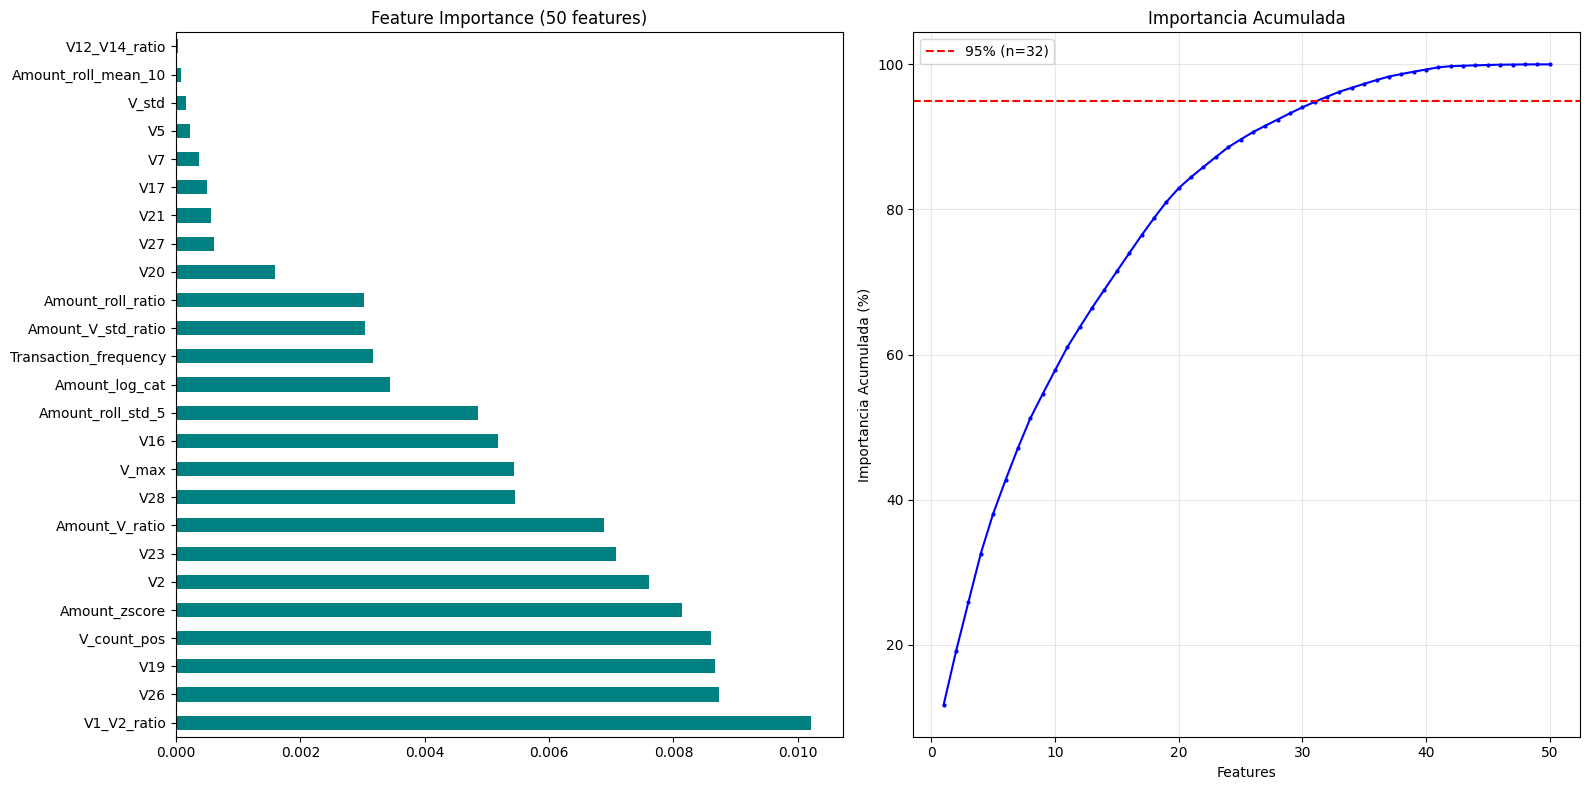

In [16]:
# Grafica de feature importance: top-25 variables (panel izq.) y curva de
# importancia acumulada con la referencia del 95% (panel der.)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
feat_imp.tail(25).plot.barh(ax=axes[0], color='teal')
axes[0].set_title(f'Feature Importance ({n_features} features)')
axes[1].plot(range(1, len(cumulative)+1), cumulative, 'b-o', markersize=2)
axes[1].axhline(y=95, color='r', linestyle='--', label=f'95% (n={n_95})')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Importancia Acumulada (%)')
axes[1].set_title('Importancia Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. LSTM (TensorFlow) - Features seleccionadas

Se entrena la primera de las dos arquitecturas de Deep Learning: una red LSTM Bidireccional que procesa ventanas de 5 transacciones consecutivas. El desbalance se trata combinando remuestreo SMOTE (aplicado sobre las secuencias ya construidas, para preservar su estructura temporal interna), ponderación de clases y una función de pérdida focal.

In [17]:
print("Entrenando LSTM...")

# --- Construir secuencias y luego aplicar SMOTE sobre ellas (en ese orden) ---
# SMOTE no entiende de "pasos de tiempo": solo interpola vectores planos. Por
# eso: (1) armamos las secuencias reales de 5x32 primero, (2) las aplanamos a
# vectores de 160 valores, (3) aplicamos SMOTE sobre esos vectores (genera
# VENTANAS sinteticas completas, no transacciones sueltas), (4) revertimos el
# aplanado a la forma 3D que espera la capa LSTM. Hacerlo al reves generaria
# ventanas armadas con filas sinteticas sin relacion temporal real entre si.
X_train_seq_raw, y_train_seq_raw = create_sequences(X_train_sel, y_train, SEQ)
N, S, F_seq = X_train_seq_raw.shape
X_train_seq_flat = X_train_seq_raw.reshape(N, S*F_seq)
smote_seq = SMOTE(sampling_strategy=0.3, random_state=42)
X_seq_bal_flat, y_train_seq = smote_seq.fit_resample(X_train_seq_flat, y_train_seq_raw)
X_train_seq = X_seq_bal_flat.reshape(-1, S, F_seq)

# Validacion y prueba SIN SMOTE: deben reflejar la distribucion real de clases
X_val_seq, y_val_seq = create_sequences(X_val_sel, y_val, SEQ)
X_test_seq, y_test_seq = create_sequences(X_test_sel, y_test, SEQ)

# --- Arquitectura ---
lstm = tf.keras.Sequential([
    # return_sequences=True: obligatorio porque la salida completa (un vector
    # por cada uno de los 5 pasos) alimenta a la siguiente capa recurrente
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True),
                                   input_shape=(SEQ, n_sel)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.BatchNormalization(),
    # return_sequences=False: es la ULTIMA capa recurrente, debe devolver un
    # solo vector resumen (no una secuencia) para el clasificador denso
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=False)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
             loss=focal_loss_tf(gamma=2.0, alpha=0.75),
             metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')])

t0 = time.time()
history_lstm = lstm.fit(X_train_seq, y_train_seq,
                        validation_data=(X_val_seq, y_val_seq),
                        epochs=100, batch_size=4096,
                        # class_weight se calculo sobre la proporcion ORIGINAL (~1:600)
                        # pero aqui se aplica sobre y_train_seq, que YA fue rebalanceado
                        # por SMOTE (~1:3.3) -> sobrepondera la clase positiva mas alla
                        # de lo que corresponderia a los datos efectivamente usados.
                        class_weight=class_weight_dict,
                        callbacks=[
                            # patience=5 sin mejorar val_loss -> detiene y restaura
                            # los pesos de la MEJOR epoca (no los de la ultima)
                            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
                            # si val_loss se estanca 4 epocas, reduce el LR a la mitad
                            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0),
                        ], verbose=0)
lstm_time = time.time() - t0
print(f"LSTM tiempo: {lstm_time:.1f}s")

# Guardar
lstm.save(f'{MODELS}/lstm_fraud_detector.keras')
print("LSTM guardado")

Entrenando LSTM...
LSTM tiempo: 64.9s
LSTM guardado


## 11. TabNet - Modelo Final (features limpias)

Se entrena la segunda arquitectura: TabNet, que procesa cada transacción de forma independiente (sin necesidad de secuenciar) sobre el conjunto completo de 50 variables, usando los mismos hiperparámetros que el TabNet preliminar de la sección 9.

In [18]:
print(f"Entrenando TabNet final ({n_features} features)...")
t0 = time.time()

# Mismos hiperparametros que el TabNet preliminar (misma arquitectura, mismo
# problema): al no cambiar la configuracion, se evita una ronda adicional de
# busqueda de hiperparametros sin una razon clara para que fuera distinta.
tabnet = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5, gamma=1.3,
    n_independent=2, n_shared=2, lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam, optimizer_params=dict(lr=1e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax', verbose=0, device_name=DEVICE)

# Entrena sobre X_bal/y_bal (50 variables, balanceado por SMOTE a nivel de
# fila individual) y valida contra X_val/y_val SIN remuestrear: la validacion
# debe reflejar la distribucion real de clases para que el early stopping
# (patience=10) sea representativo del desempeño en produccion.
tabnet.fit(X_bal, y_bal, eval_set=[(X_val, y_val)],
           eval_metric=['auc', 'logloss'], max_epochs=50, patience=10,
           batch_size=4096, virtual_batch_size=512)

tabnet_time = time.time() - t0
print(f"TabNet tiempo: {tabnet_time:.1f}s")

# save_model agrega automaticamente la extension .zip al nombre de archivo
tabnet.save_model(f'{MODELS}/tabnet_fraud_detector')
print("TabNet guardado")

Entrenando TabNet final (50 features)...

Early stopping occurred at epoch 43 with best_epoch = 33 and best_val_0_logloss = 0.00669
TabNet tiempo: 257.2s
Successfully saved model at /content/drive/MyDrive/TRABAJO FINAL - DEEP LEARNING/models/tabnet_fraud_detector.zip
TabNet guardado


## 12. Evaluación Comparativa

Esta es la celda metodológicamente más importante del notebook: el umbral de decisión de cada modelo se busca **exclusivamente con predicciones y etiquetas de validación**; el conjunto de prueba solo se utiliza después, con el umbral ya fijo, para calcular las métricas finales que se reportan. Ajustar el umbral mirando directamente las etiquetas de prueba habría producido métricas optimistas y no representativas del desempeño real del sistema.

In [19]:
# y_test[SEQ-1:]: create_sequences descarta las primeras SEQ-1=4 filas (no hay
# ventana completa de 5 pasos que TERMINE en la fila 0,1,2 o 3). Este recorte
# re-alinea y_test, indice a indice, con las predicciones del LSTM (que ya
# vienen 4 mas cortas). El mismo recorte se aplica a TabNet mas abajo, aunque
# TabNet no necesita secuencias, solo para comparar ambos modelos sobre el
# EXACTO mismo subconjunto de filas.
y_true = y_test[SEQ-1:]

# Predicciones en TEST
lstm_probs = lstm.predict(X_test_seq, verbose=0).flatten()
tabnet_probs = tabnet.predict_proba(X_test)[:, 1][SEQ-1:]  # [:,1] = prob. de la clase fraude

# Predicciones en VAL para encontrar threshold optimo (sin ver test)
lstm_val_probs = lstm.predict(X_val_seq, verbose=0).flatten()
tabnet_val_probs = tabnet.predict_proba(X_val)[:, 1][SEQ-1:]
y_val_true = y_val[SEQ-1:]

# --- Paso metodologicamente clave: el umbral se busca SOLO con datos de
# VALIDACION. El conjunto de test recien se toca despues, ya con el umbral
# fijo, unicamente para calcular las metricas finales. ---
# Thresholds optimizados en VALIDATION (no en test)
t_lstm, _ = find_best_threshold(y_val_true, lstm_val_probs)
t_tabnet, _ = find_best_threshold(y_val_true, tabnet_val_probs)

# Evaluar en TEST (con el umbral ya fijado en validacion)
r_lstm = evaluate_model(y_true, (lstm_probs > t_lstm).astype(int), lstm_probs, 'LSTM')
r_lstm['threshold'] = t_lstm
r_tabnet = evaluate_model(y_true, (tabnet_probs > t_tabnet).astype(int), tabnet_probs, 'TabNet')
r_tabnet['threshold'] = t_tabnet

# Referencia: mejor F1 teorico en test (vectorizado) -> cota superior NO
# alcanzable en produccion (usa las etiquetas de test para elegir el umbral)
lstm_best_f1 = best_f1(y_true, lstm_probs)
tabnet_best_f1 = best_f1(y_true, tabnet_probs)
print(f"LSTM -> F1 teorico: {lstm_best_f1:.4f}")
print(f"TabNet -> F1 teorico: {tabnet_best_f1:.4f}")

# Mostrar resultados detallados
print("=" * 80)
print("RESULTADOS FINALES")
print("=" * 80)
print(f"\n{'Modelo':<20} {'P':>8} {'R':>8} {'F1':>8} {'ROC-AUC':>9} {'ROI':>10} {'Net':>12}")
print("-" * 80)
for r in [r_lstm, r_tabnet]:
    print(f"{r['model']:<20} {r['precision']:>8.4f} {r['recall']:>8.4f} "
          f"{r['f1']:>8.4f} {r['roc_auc']:>9.4f} "
          f"{r['roi']:>9.1f}% ${r['net_benefit']:>10,.0f}")

print(f"\nTiempos: LSTM={lstm_time:.1f}s, TabNet={tabnet_time:.1f}s")

LSTM -> F1 teorico: 0.8000
TabNet -> F1 teorico: 0.8030
RESULTADOS FINALES

Modelo                      P        R       F1   ROC-AUC        ROI          Net
--------------------------------------------------------------------------------
LSTM                   0.7237   0.7746   0.7483    0.9554     182.1% $     5,325
TabNet                 0.7465   0.7465   0.7465    0.9495     152.4% $     4,800

Tiempos: LSTM=64.9s, TabNet=257.2s


## 13. Gráficas Comparativas

Se visualizan las curvas ROC y Precision-Recall de ambos modelos sobre el conjunto de prueba, junto con sus matrices de confusión (subsección 13.1).

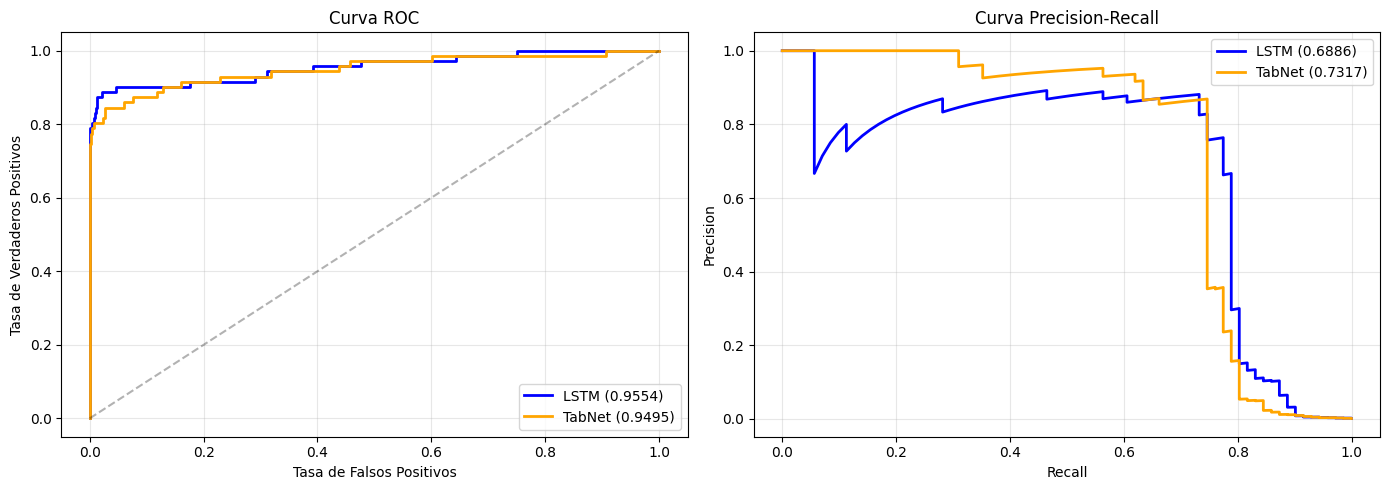

In [20]:
# Curvas ROC y Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC: FPR vs TPR a traves de TODOS los umbrales ---
for probs, name, color in [(lstm_probs, 'LSTM', 'blue'), (tabnet_probs, 'TabNet', 'orange')]:
    fpr, tpr, _ = roc_curve(y_true, probs)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} ({roc_auc_score(y_true, probs):.4f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.3)  # diagonal = clasificador aleatorio, como referencia
axes[0].set_title('Curva ROC')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Precision-Recall: mas informativa que ROC bajo desbalance severo ---
for probs, name, color in [(lstm_probs, 'LSTM', 'blue'), (tabnet_probs, 'TabNet', 'orange')]:
    p, rv, _ = precision_recall_curve(y_true, probs)
    axes[1].plot(rv, p, color=color, linewidth=2, label=f'{name} ({average_precision_score(y_true, probs):.4f})')
axes[1].set_title('Curva Precision-Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 13.1 Matrices de Confusión

Se grafican, lado a lado, las matrices de confusión de LSTM y TabNet sobre el conjunto de prueba, con Precision/Recall/F1 incrustados en el título de cada panel.

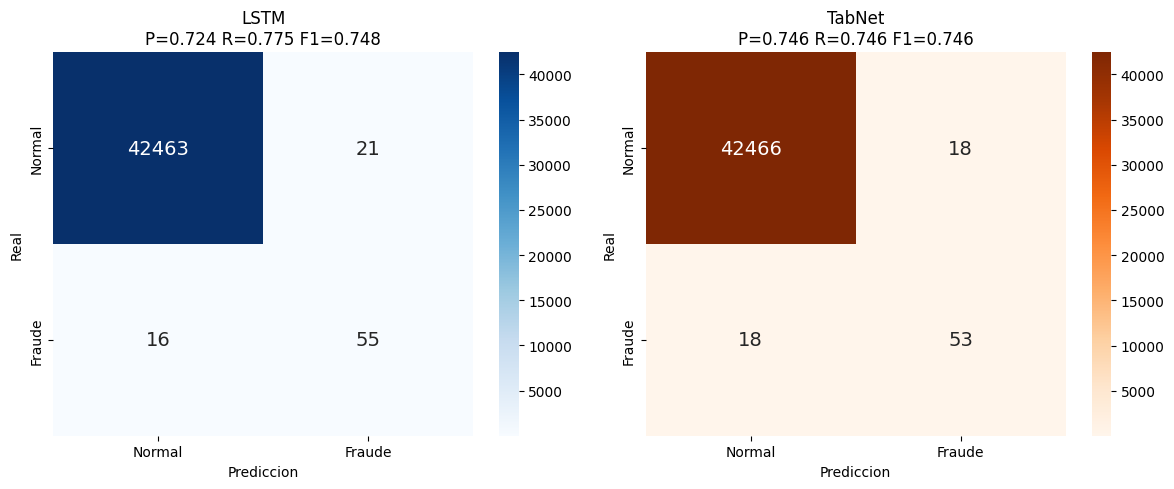

In [21]:
# Matrices de confusion separadas por modelo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, r, name, c in [
    (axes[0], r_lstm, 'LSTM', 'Blues'),
    (axes[1], r_tabnet, 'TabNet', 'Oranges')
]:
    # r['cm'] es la matriz de confusion que evaluate_model() guardo en cada
    # diccionario de resultados; fmt='d' fuerza a mostrar enteros (conteos)
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap=c, ax=ax,
                xticklabels=['Normal','Fraude'], yticklabels=['Normal','Fraude'],
                annot_kws={'size':14})
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')
    ax.set_title(f"{r['model']}\nP={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1']:.3f}")

plt.tight_layout()
plt.show()

## 14. Guardar Resultados

Se serializan en Google Drive dos artefactos: el diccionario de métricas y metadatos del experimento (`results.pkl`) y los escaladores ya ajustados (`scaler.pkl`) — estos últimos indispensables si el sistema se desplegara, ya que cualquier transacción nueva debe transformarse con los mismos parámetros aprendidos de entrenamiento, nunca con un escalador reajustado sobre datos entrantes.

In [22]:
# Guardar resultados
results = {
    'lstm': {k: v for k, v in r_lstm.items() if k != 'cm'},
    'tabnet': {k: v for k, v in r_tabnet.items() if k != 'cm'},
    'selected_features': selected_features,
    'n_features': n_sel,
    'times': {'lstm': lstm_time, 'tabnet': tabnet_time},
}

with open(f'{MODELS}/results.pkl', 'wb') as f:
    pickle.dump(results, f)

# El scaler entrenado tambien se guarda: si este sistema se desplegara,
# cualquier transaccion nueva debe transformarse con estos MISMOS parametros
# (aprendidos de train), nunca reajustando un scaler nuevo sobre datos entrantes.
with open(f'{MODELS}/scaler.pkl', 'wb') as f:
    pickle.dump({'robust': scaler_robust, 'standard': scaler_standard}, f)

print("Resultados guardados en Google Drive")
print(f"\nArchivos en {MODELS}:")
for f in os.listdir(MODELS):
    print(f"  - {f}")

Resultados guardados en Google Drive

Archivos en /content/drive/MyDrive/TRABAJO FINAL - DEEP LEARNING/models:
  - lstm_fraud_detector_20260729_0141.keras
  - tabnet_fraud_detector_20260729_0141.zip
  - results_20260729_0141.pkl
  - scaler_20260729_0141.pkl
  - lstm_fraud_detector_v2_20260729_0214.keras
  - tabnet_fraud_detector_v2_20260729_0214.zip
  - results_v2_20260729_0214.pkl
  - scaler_v2_20260729_0214.pkl
  - lstm_fraud_detector.keras
  - tabnet_fraud_detector.zip
  - results.pkl
  - scaler.pkl


## 15. Resumen Final

Tabla comparativa final entre ambos modelos (variables usadas, ROI, F1-Score, beneficio neto) y determinación automática de cuál obtuvo el mejor resultado en cada criterio.

In [23]:
# Resumen Final Dinamico
print("=" * 70)
print("RESUMEN FINAL")
print("=" * 70)
print(f"{'Modelo':<20} {'Features':>10} {'ROI':>10} {'F1':>8} {'Net Benefit':>14}")
print("-" * 70)
print(f"{'LSTM':<20} {n_sel:>10d} {r_lstm['roi']:>8.1f}% {r_lstm['f1']:>8.3f} ${r_lstm['net_benefit']:>10,.0f}")
print(f"{'TabNet':<20} {n_features:>10d} {r_tabnet['roi']:>8.1f}% {r_tabnet['f1']:>8.3f} ${r_tabnet['net_benefit']:>10,.0f}")
print("-" * 70)
# max(..., key=...) compara los diccionarios por el campo indicado en key,
# no por el diccionario completo (que no seria comparable directamente)
best_roi = max([r_lstm, r_tabnet], key=lambda x: x['roi'])
best_f1_model = max([r_lstm, r_tabnet], key=lambda x: x['f1'])
best_net = max([r_lstm, r_tabnet], key=lambda x: x['net_benefit'])
print(f"Mejor ROI: {best_roi['model']} ({best_roi['roi']:.1f}%)")
print(f"Mejor F1: {best_f1_model['model']} ({best_f1_model['f1']:.3f})")
print(f"Mejor Net Benefit: {best_net['model']} (${best_net['net_benefit']:,.0f})")
print(f"Referencia F1 teorico (best_f1): LSTM={lstm_best_f1:.4f}, TabNet={tabnet_best_f1:.4f}")

RESUMEN FINAL
Modelo                 Features        ROI       F1    Net Benefit
----------------------------------------------------------------------
LSTM                         32    182.1%    0.748 $     5,325
TabNet                       50    152.4%    0.746 $     4,800
----------------------------------------------------------------------
Mejor ROI: LSTM (182.1%)
Mejor F1: LSTM (0.748)
Mejor Net Benefit: LSTM ($5,325)
Referencia F1 teorico (best_f1): LSTM=0.8000, TabNet=0.8030
